# Working with PCR-GLOBWB: a practical workflow example

This notebook is meant to show how to work with PCR-GLOBWB in practice using a concrete sensitivity experiment as an example.

The focus is not the experiment itself, but the general workflow:

- define the study period,
- load the model parameter set and forcing data,
- initialize one or more model runs,
- apply a controlled perturbation to a state variable,
- run the model, save outputs, and interpret the response.

The channel-storage manipulation below is therefore used as a demonstration of the modeling workflow, rather than as the main scientific result. The same structure can be reused for other experiments, such as changes in precipitation, routing, groundwater storage, or parameter choices.

## Why this workflow matters

When working with a process-based hydrological model, the most important skill is not only running the model once, but setting up a reproducible experiment in a way that keeps the baseline, the perturbation, and the output analysis clearly separated. This notebook shows a simple pattern for doing that in a transparent and reproducible way.


In [1]:
import sys
from datetime import datetime
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from cartopy import feature as cfeature
from matplotlib.colors import LogNorm
from tqdm.notebook import tqdm

import ewatercycle.forcing
import ewatercycle.models
import ewatercycle.observation.grdc
import ewatercycle.parameter_sets
from ewatercycle.container import ContainerImage



# Note:
# The imports below are kept intentionally minimal and are only used for the
# thesis experiment documented in this notebook.


/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [2]:
import sys
import ewatercycle_pcrglobwb

print("Python:", sys.executable)
print("Package:", ewatercycle_pcrglobwb.__file__)

Python: /home/avandervee3/MSc_AralSea/venv/bin/python
Package: /home/avandervee3/ewatercycle-pcrglobwb/src/ewatercycle_pcrglobwb/__init__.py


In [3]:
import importlib.metadata

print(importlib.metadata.version("ewatercycle-pcrglobwb"))

0.2.1


In [4]:
# Define project root to access local thesis utilities
PROJECT_ROOT = Path().resolve().parents[2]
sys.path.append(str(PROJECT_ROOT))

from src.aral import load_grdc_monthly
from src.constants import STATIONS_PCR
from src.paths import FORCING_PCRGLOB, GRDC, INI_FILES, LOAD_PCR, PCR_GLOBAL_PARAMS, PCR_TAIL


In [5]:
STATIONS_PCR


{'Chatly': {'lat': 42.2, 'lon': 60.2},
 'Kazalinsk': {'lat': 45.7, 'lon': 62.12},
 'Kerki': {'lat': 37.83, 'lon': 65.3},
 'Tyumen-Aryk': {'lat': 43.95, 'lon': 67.05},
 'Uch-Kurgan': {'lat': 41.12, 'lon': 72.1},
 'Garm': {'lat': 39.05, 'lon': 70.33}}

In [6]:
tools_folder = Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/tools")

rivers_buffer_10km = tools_folder / "aral_basin_ad_sd_rivers_buffer_10_05min_mask.map"

In [7]:
# This notebook uses a custom PCR-GLOBWB parameter set and a prepared forcing dataset.
# The parameter set points to the local model data directory and a study-specific ini file.

pcr_glob_directory = PCR_GLOBAL_PARAMS
prepared_pcr_forcing = FORCING_PCRGLOB / LOAD_PCR / PCR_TAIL

# For reproducibility, we keep the expected model directory explicit.
pcr_glob_directory = Path("/data/shared/parameter-sets/pcrglobwb_global")

parameter_set_test = ewatercycle.parameter_sets.ParameterSet(
    name="custom_parameter_set",
    directory=pcr_glob_directory,
    config=INI_FILES / "calibrated_best_save_discharge.ini",
    target_model="pcrglobwb",
    supported_model_versions={"aralxy5"},
)

forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
    directory=prepared_pcr_forcing,
)

my_image = ContainerImage("/home/avandervee3/pcrglob_aralxy5.sif")

In [27]:
INI_FILES

PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/ini_files')

In [8]:
# Create separate model instances for the baseline and experimental runs.
# Each instance is initialized independently, so the perturbation can be applied
# without changing the reference state.

baseline_model = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image,
)

addition_model = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image,
)

different_clonemap_model = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image,  cloneMap=rivers_buffer_10km, landmask=rivers_buffer_10km, 
)


print(different_clonemap_model)


parameter_set=ParameterSet(name='custom_parameter_set', directory=PosixPath('/data/shared/parameter-sets/pcrglobwb_global'), config=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/pcrglobwb/ini_files/calibrated_best_save_discharge.ini'), doi='N/A', target_model='pcrglobwb', supported_model_versions={'aralxy5'}, downloader=None) forcing=PCRGlobWBForcing(start_time='1940-01-01T00:00:00Z', end_time='1960-12-31T00:00:00Z', directory=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/PCRGLOBWB/ERA5_1940-1960/AralSea_basin/work/diagnostic/script'), shape=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/PCRGLOBWB/ERA5_1940-1960/AralSea_basin/work/diagnostic/script/AralSea_basin.shp'), filenames={}, precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1940-1960_AralSea_b

In [9]:
prepared_pcr_forcing

PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/PCRGLOBWB/ERA5_1940-1960/AralSea_basin/work/diagnostic/script')

In [10]:
# Define the short experimental period used for the sensitivity test.
experiment_start_date = "1949-11-01T00:00:00Z"
experiment_end_date = "1950-09-30T00:00:00Z"


In [11]:
from pathlib import Path
import shutil

# Remove previous experiment directories before setup to keep the notebook reproducible.
for cfg_dir in [
    Path("channel_experiment_reference"),
    Path("channel_experiment_different_clonemap"),
    Path("channel_experiment_addition"),
]:
    if cfg_dir.exists():
        shutil.rmtree(cfg_dir)

baseline_config, baseline_dir = baseline_model.setup(
    start_time=experiment_start_date,
    end_time=experiment_end_date,
    max_spinups_in_years=2,
    cfg_dir="channel_experiment_reference",
)
baseline_config, baseline_dir


addition_config, addition_dir = addition_model.setup(
    start_time=experiment_start_date,
    end_time=experiment_end_date,
    max_spinups_in_years=2,
    cfg_dir="channel_experiment_addition",
)
addition_config, addition_dir



different_clonemap_config, different_clonemap_dir = different_clonemap_model.setup(
    start_time=experiment_start_date,
    end_time=experiment_end_date,
    max_spinups_in_years=2,
    cfg_dir="channel_experiment_different_clonemap",
)
different_clonemap_config, different_clonemap_dir



('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/Report/notebooks/channel_experiment_different_clonemap/pcrglobwb_ewatercycle.ini',
 '/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/Report/notebooks/channel_experiment_different_clonemap')

In [12]:
# Explore the model parameters to confirm the setup and inspect the available
# configuration values before the experiment starts.
print(baseline_model.parameters)

baseline_parameters = baseline_model.parameters

# Convert ISO 8601 strings to datetime objects for progress tracking.
start_time = datetime.strptime(experiment_start_date, "%Y-%m-%dT%H:%M:%SZ")
end_time = datetime.strptime(experiment_end_date, "%Y-%m-%dT%H:%M:%SZ")

delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")


dict_items([('start_time', '1949-11-01T00:00:00Z'), ('end_time', '1950-09-30T00:00:00Z'), ('routing_method', 'accuTravelTime'), ('max_spinups_in_years', '2')])
Number of days to model: 333


## General workflow for a PCR-GLOBWB experiment

The model is initialized for a short time window, and the same forcing is used for each run so that differences arise only from the controlled intervention.

In this example, three model instances are compared:

- a baseline reference run,
- a single-cell channel-storage reduction,
- a multi-cell channel-storage reduction.

This pattern is useful because it isolates the effect of the perturbation while keeping the rest of the model configuration fixed. In a broader workflow, the same structure can be reused for other variables or sensitivity tests.

The key idea is simple: keep the baseline as a reference, apply a controlled change to a state variable, and compare the resulting model response.


In [13]:
baseline_model.initialize(baseline_config)
addition_model.initialize(addition_config)
different_clonemap_model.initialize(different_clonemap_config)



In [14]:
# Create a time index for the output records.
time = pd.date_range(baseline_model.start_time_as_isostr, baseline_model.end_time_as_isostr)
stations_timeseries = pd.DataFrame(
    index=pd.Index(time, name="time"), columns=["Chatly", "Kerki", "Tyumen", "Kazalinsk"]
)
stations_timeseries.head()


,Chatly,Kerki,Tyumen,Kazalinsk
time,,,,
1949-11-01 00:00:00+00:00,NaN,NaN,NaN,NaN
1949-11-02 00:00:00+00:00,NaN,NaN,NaN,NaN
1949-11-03 00:00:00+00:00,NaN,NaN,NaN,NaN
1949-11-04 00:00:00+00:00,NaN,NaN,NaN,NaN
1949-11-05 00:00:00+00:00,NaN,NaN,NaN,NaN


In [15]:
# These coordinates define the cells selected for the multi-cell storage perturbation.
# They are intended to represent a spatially clustered intervention in the channel network.
lat_idx = 61
lon_idx = 127




In [16]:
# The experiment compares the model response under two different perturbation patterns:
# 1) a single-cell reduction in channel storage, and
# 2) a multi-cell reduction distributed across several nearby cells.
#
# The target is a daily removal equivalent to 10 km^3 yr^-1, converted to the model's
# internal volume units. A clipped scaling factor is used to prevent extreme depletion
# in cells with already low storage.

import numpy as np
import pandas as pd
import xarray as xr
from tqdm import tqdm

DAILY_REMOVAL_TARGET = 50 * 1e9 / 365

history_2x = []
history_multiple = []
history_addition = []
timestamps = []

for i in tqdm(range(number_of_days), desc="Running sensitivity experiment"):
    baseline_model.update()
    addition_model.update()
    different_clonemap_model.update()

    current_time = pd.to_datetime(baseline_model.time_as_isostr)
    timestamps.append(current_time)

    

    # --- addition experiment: add water to a single cell to observe the response ---
    addition_var = addition_model.get_value_as_xarray("channel_storage")
    addition_values = addition_var.values.copy()

    addition_values[lat_idx, lon_idx] += DAILY_REMOVAL_TARGET

    addition_model.set_value(
        "channel_storage",
        addition_values.flatten(),
    )


    



print("experiments finished.")


Running sensitivity experiment: 100%|██████████| 333/333 [51:04<00:00,  9.20s/it] 

experiments finished.


In [17]:

folders = [
    Path("channel_experiment_reference"),
    Path("channel_experiment_addition"),
    Path("channel_experiment_different_clonemap"),
]

datasets = {
    folder.name: xr.open_dataset(
        folder / "netcdf" / "discharge_dailyTot_output.nc"
    )
    for folder in folders
}

lat_point = 40
lon_point = 62.45

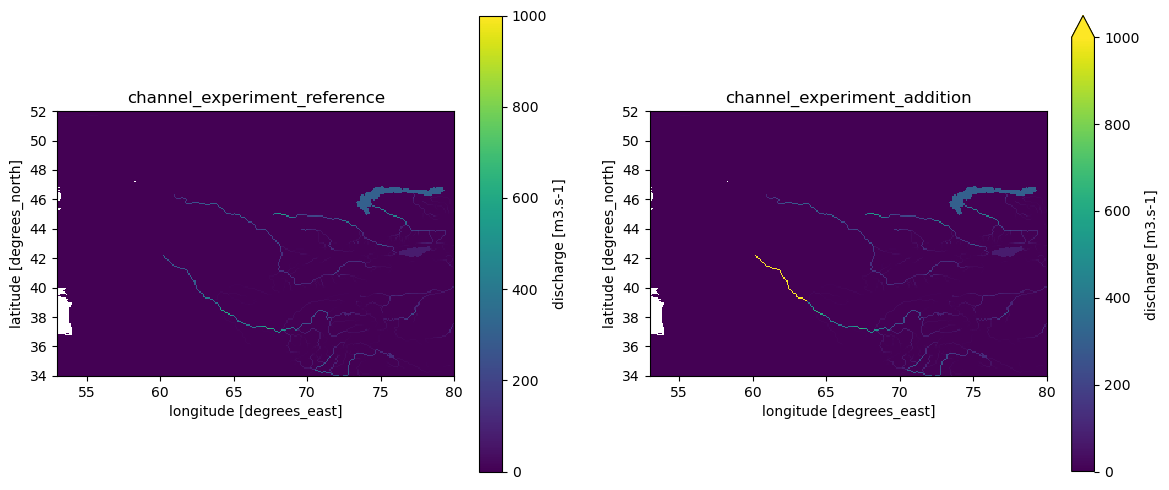

In [18]:
# Reference and addition
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name in zip(
    axes,
    ["channel_experiment_reference", "channel_experiment_addition"],
):
    ds = datasets[name]

    ds.isel(time=-1).discharge.plot(
        ax=ax,
        vmin=0,
        vmax=1000,
    )
    ax.set_title(name)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()




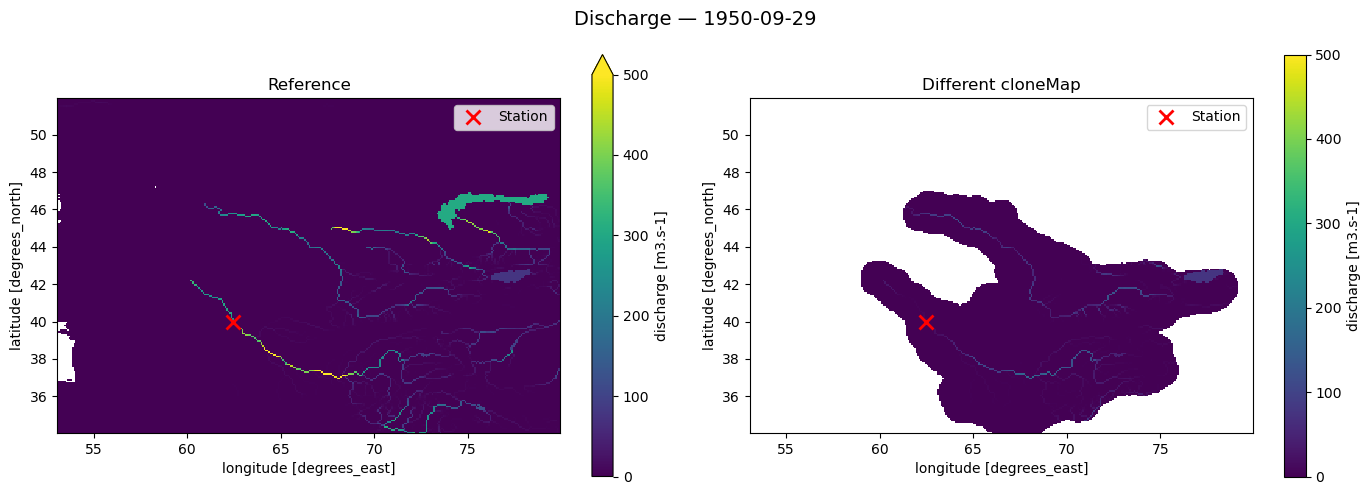

In [19]:
reference = datasets["channel_experiment_reference"]
different_clonemap = datasets["channel_experiment_different_clonemap"]

lat_min = reference.lat.min().item()
lat_max = reference.lat.max().item()
lon_min = reference.lon.min().item()
lon_max = reference.lon.max().item()

# Date of the plotted timestep
date = reference.time.isel(time=-1).dt.strftime("%Y-%m-%d").item()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reference.isel(time=-1).discharge.plot(
    ax=axes[0],
    x="lon",
    y="lat",
    vmin=0,
    vmax=500,
)
axes[0].plot(
    lon_point,
    lat_point,
    "rx",
    markersize=10,
    markeredgewidth=2,
    label="Station",
)
axes[0].set_title("Reference")
axes[0].set_xlim(lon_min, lon_max)
axes[0].set_ylim(lat_min, lat_max)
axes[0].set_aspect("equal")
axes[0].legend()

different_clonemap.isel(time=-1).discharge.plot(
    ax=axes[1],
    x="lon",
    y="lat",
    vmin=0,
    vmax=500,
)
axes[1].plot(
    lon_point,
    lat_point,
    "rx",
    markersize=10,
    markeredgewidth=2,
    label="Station",
)
axes[1].set_title("Different cloneMap")
axes[1].set_xlim(lon_min, lon_max)
axes[1].set_ylim(lat_min, lat_max)
axes[1].set_aspect("equal")
axes[1].legend()

fig.suptitle(f"Discharge — {date}", fontsize=14)

plt.tight_layout()
plt.show()

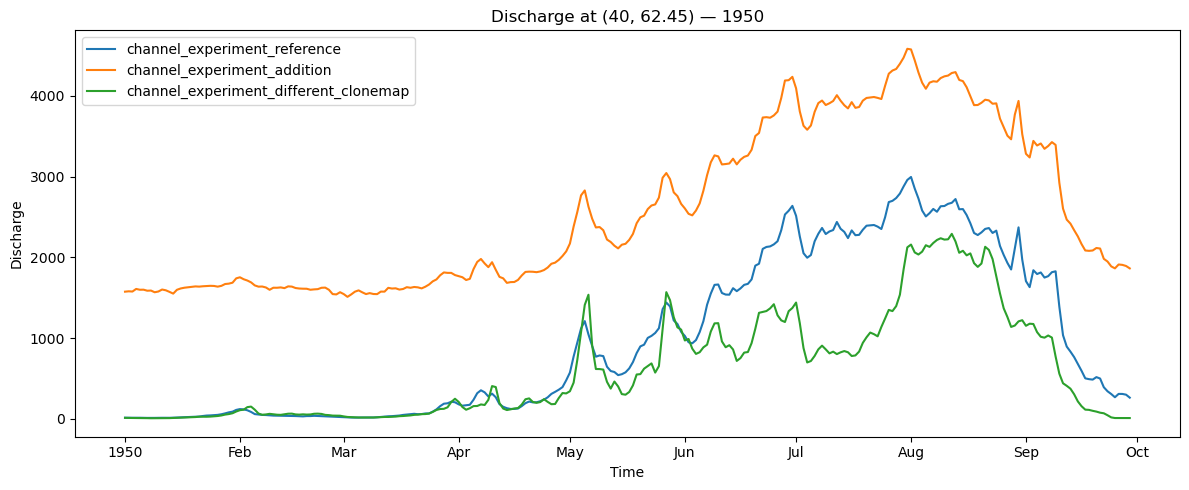

In [20]:
plt.figure(figsize=(12, 5))

for name, ds in datasets.items():
    ts = ds.discharge.sel(
        lat=lat_point,
        lon=lon_point,
        method="nearest"
    ).sel(time="1950")

    ts.plot(label=name)

plt.xlabel("Time")
plt.ylabel("Discharge")
plt.title(f"Discharge at ({lat_point}, {lon_point}) — 1950")
plt.legend()
plt.tight_layout()
plt.show()

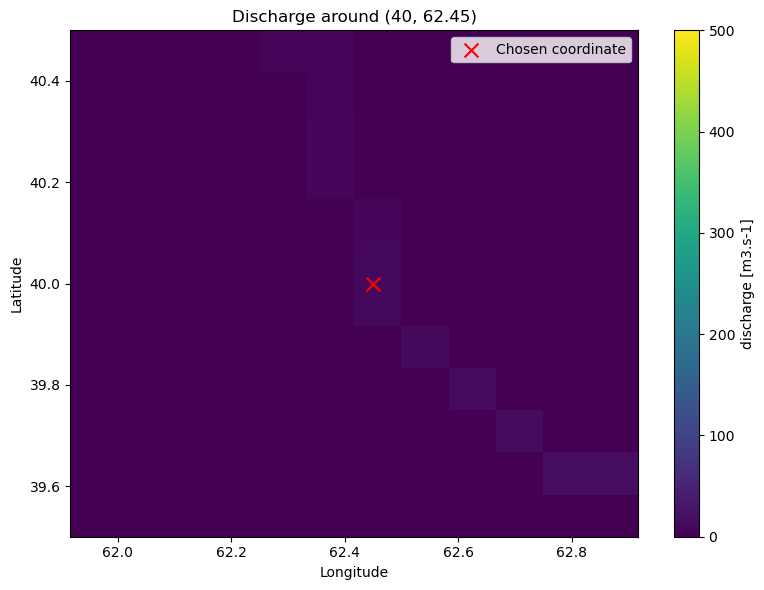

In [21]:
lat_point = 40
lon_point = 62.45

radius = 0.5  # degrees around the point

# Account for either ascending or descending latitude
if ds.lat[0] < ds.lat[-1]:
    lat_slice = slice(lat_point - radius, lat_point + radius)
else:
    lat_slice = slice(lat_point + radius, lat_point - radius)

area = ds.discharge.sel(
    lat=lat_slice,
    lon=slice(lon_point - radius, lon_point + radius)
).isel(time=-1)

fig, ax = plt.subplots(figsize=(8, 6))

area.plot(
    ax=ax,
    vmin=0,
    vmax=500,
)

# Mark your chosen coordinate
ax.scatter(
    lon_point,
    lat_point,
    marker="x",
    s=100,
    color="red",
    label="Chosen coordinate"
)

ax.set_title(f"Discharge around ({lat_point}, {lon_point})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()

plt.tight_layout()
plt.show()

In [22]:
point = ds.discharge.sel(
    lat=lat_point,
    lon=lon_point,
    method="nearest"
)

print(point.lat.values, point.lon.values)

40.041668 62.458332


In [23]:
# import numpy as np
# import xarray as xr

# # Export the single-cell time series as a NetCDF file for reference and later plotting.
# datetime_timestamps = np.array(timestamps, dtype="datetime64[ns]")

# ds_2x = xr.Dataset(
#     data_vars={
#         "storage_change": ("time", history_2x)
#     },
#     coords={
#         "time": datetime_timestamps
#     }
# )
# ds_2x.storage_change.attrs["units"] = "same as model"
# ds_2x.to_netcdf("history_single_cell.nc")

# # Export the multi-cell experiment in structured spatial form.
# unique_lats = sorted(list(set(c[0] for c in coords_3)))
# unique_lons = sorted(list(set(c[1] for c in coords_3)))

# grid_data = np.zeros((len(datetime_timestamps), len(unique_lats), len(unique_lons)))
# lat_map = {lat: i for i, lat in enumerate(unique_lats)}
# lon_map = {lon: i for i, lon in enumerate(unique_lons)}

# for t_idx, daily_dict in enumerate(history_multiple):
#     for coord, value in daily_dict.items():
#         if coord in coords_3:
#             lat_idx = lat_map[coord[0]]
#             lon_idx = lon_map[coord[1]]
#             grid_data[t_idx, lat_idx, lon_idx] = value

# ds_multiple = xr.Dataset(
#     data_vars={
#         "storage_change": (["time", "lat", "lon"], grid_data)
#     },
#     coords={
#         "time": datetime_timestamps,
#         "lat": unique_lats,
#         "lon": unique_lons
#     }
# )

# ds_multiple.storage_change.attrs["units"] = "same as model"

# try:
#     ds_multiple.to_netcdf("history_multiple_cells.nc")
#     print("Saved 'history_multiple_cells.nc' successfully.")
# except Exception as e:
#     print(f"Failed to save NetCDF file: {e}")

# print("Saved both NetCDF files successfully.")


In [24]:
# import matplotlib.pyplot as plt

# # The following plots show how the storage perturbation propagates through time.
# # They are intended to summarize the experiment visually in a way that is easy to
# # interpret in a thesis chapter or presentation.

# plt.figure(figsize=(10, 4))
# plt.plot(ds_2x["time"], ds_2x["storage_change"], marker="o", color="b", linestyle="-")
# plt.title("Single-cell storage change over time")
# plt.xlabel("Time")
# plt.ylabel(f"Storage change ({ds_2x['storage_change'].attrs.get('units', 'same as model')})")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# total_storage_change = ds_multiple["storage_change"].sum(dim=["lat", "lon"])

# plt.figure(figsize=(10, 4))
# plt.plot(ds_multiple["time"], total_storage_change, marker="o", color="g", linestyle="-")
# plt.title("Total storage change for all perturbed cells")
# plt.xlabel("Time")
# plt.ylabel(f"Total storage change ({ds_multiple['storage_change'].attrs.get('units', 'same as model')})")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


In [25]:
baseline_model.finalize()
addition_model.finalize()
different_clonemap_model.finalize()

## Interpretation

The two experiments illustrate how the model responds to channel-storage perturbations under different spatial assumptions.

- The single-cell experiment isolates the response of one local channel cell and helps reveal the immediate, localized sensitivity of the storage term.
- The multi-cell experiment distributes the same total perturbation across several cells, producing a broader and more spatially integrated response.

This comparison supports the interpretation that the model reacts in a physically plausible way to storage changes, while also highlighting that the response depends on where the perturbation is applied.

## Conclusion

This notebook shows a compact sensitivity experiment that is useful for a thesis workflow: it tests model responsiveness, demonstrates the effect of channel-storage manipulation, and provides a transparent record of how the experiment was implemented.

The results should be interpreted as a sensitivity analysis rather than a final calibration step. The objective here is to better understand the model behavior in a controlled setting before drawing conclusions about the larger hydrological system.
